# Capacitated Power Dominating Set

### Parameters:
TIMEOUT = 900 (seconds)</br>
NRUNS = 5</br>
ALL-Z = False (not all vertices can propagate)</br>

## Import packages

In [1]:
from tools import *

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Read data

In [2]:
df_stats1 = pd.read_csv("stats1.csv", index_col=0)
df_stats2 = pd.read_csv("stats2.csv", index_col=0)
df_stats3 = pd.read_csv("stats3.csv", index_col=0)

df = pd.concat([df_stats1, df_stats2, df_stats3], ignore_index=True)

Clean the data.

In [3]:
# Change column name "omega" to "k"
df = df.rename(columns={"omega": "k"})

# Handle instances where no solution was found
df.loc[df.upper_bound == -1.0, "upper_bound"] = float("nan")
df.loc[df.gap == 100.0, "gap"] = float("nan")

# Handle instance with timeout
timeout = 900000000 # 900000000 microseconds = 900 seconds = 15 minutes
df.loc[df.result == "Timeout", "t_solver"] = timeout

# Transform microseconds to seconds
timeout = int(timeout / 1000000)
df.t_solver = df.t_solver / 1000000
df.t_callback = df.t_callback / 1000000

# Clean instance names
df.instance = df.instance.apply(lambda x: x.split("/")[-1])
df.instance = df.instance.apply(lambda x: x.split(".")[0])
df.instance = df.instance.apply(lambda x: x.removeprefix("case_"))
df.instance = df.instance.apply(lambda x: x.removeprefix("case"))

# Remove instances with less than 200 vertices
df = df[(df.vertices >= 200)]

# Remove models that are not considered in the article
cuts = ["efpss-outp-init-cuts1m100f", 
        "efpss-outp-init-cuts1m1000f", 
        "efpss-outp-init-cuts5m100f", 
        "efpss-outp-init-cuts5m1000f",
        "efpss-inp-outp-init"]
df = df[~df.solver.isin(cuts)]

# Rename solvers
solver_map = {"brimkov": 'BRI-IP',
              "jovanovic": 'JOV-IP',
              "forts": 'FORT-IP',
              "efpss": "EFPS-IP",
              "efpss-inp": "EFPS-IP-InP",
              "efpss-outp": "EFPS-IP-OutP",
              "efpss-inp-outp": "EFPS-IP-InP-OutP",
              "efpss-outp-init": "EFPS-IP-OutP-Init",
              "fpss": "FPS-IP"
              }
df.solver = df.solver.apply(lambda x: solver_map[x])

# Sort values
df = df.sort_values(["vertices", "solver", "k", "run"], ignore_index=True)
df

,solver,instance,vertices,edges,propagating_vertices,k,variables,constraints,run,lower_bound,upper_bound,gap,result,nodes,t_solver,callbacks,t_callback,lazy_constraints
0,BRI-IP,illinois200,200,245,44,0,1074,1304,0,156.0,156.0,0.0,Optimal,1,0.061905,0,0.0,0
1,BRI-IP,illinois200,200,245,44,0,1074,1304,1,156.0,156.0,0.0,Optimal,1,0.058577,0,0.0,0
2,BRI-IP,illinois200,200,245,44,0,1074,1304,2,156.0,156.0,0.0,Optimal,1,0.058100,0,0.0,0
3,BRI-IP,illinois200,200,245,44,0,1074,1304,3,156.0,156.0,0.0,Optimal,1,0.058234,0,0.0,0
4,BRI-IP,illinois200,200,245,44,0,1074,1304,4,156.0,156.0,0.0,Optimal,1,0.058140,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18625,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,0,2721.0,2721.0,0.0,Optimal,1810,114.208638,0,0.0,0
18626,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,1,2721.0,2721.0,0.0,Optimal,1810,113.605977,0,0.0,0
18627,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,2,2721.0,2721.0,0.0,Optimal,1810,113.291765,0,0.0,0
18628,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,3,2721.0,2721.0,0.0,Optimal,1810,113.382452,0,0.0,0


## Check solutions

In [4]:
def opt_val(serie):
    if serie.result == "Optimal":
        return serie.upper_bound
    else:
        return float("nan")

df["opt_val"] = df[["result", "upper_bound"]].apply(opt_val, axis=1)
df

,solver,instance,vertices,edges,propagating_vertices,k,variables,constraints,run,lower_bound,upper_bound,gap,result,nodes,t_solver,callbacks,t_callback,lazy_constraints,opt_val
0,BRI-IP,illinois200,200,245,44,0,1074,1304,0,156.0,156.0,0.0,Optimal,1,0.061905,0,0.0,0,156.0
1,BRI-IP,illinois200,200,245,44,0,1074,1304,1,156.0,156.0,0.0,Optimal,1,0.058577,0,0.0,0,156.0
2,BRI-IP,illinois200,200,245,44,0,1074,1304,2,156.0,156.0,0.0,Optimal,1,0.058100,0,0.0,0,156.0
3,BRI-IP,illinois200,200,245,44,0,1074,1304,3,156.0,156.0,0.0,Optimal,1,0.058234,0,0.0,0,156.0
4,BRI-IP,illinois200,200,245,44,0,1074,1304,4,156.0,156.0,0.0,Optimal,1,0.058140,0,0.0,0,156.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18625,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,0,2721.0,2721.0,0.0,Optimal,1810,114.208638,0,0.0,0,2721.0
18626,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,1,2721.0,2721.0,0.0,Optimal,1810,113.605977,0,0.0,0,2721.0
18627,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,2,2721.0,2721.0,0.0,Optimal,1810,113.291765,0,0.0,0,2721.0
18628,JOV-IP,13659pegase,13659,18625,4024,41,39823,153138,3,2721.0,2721.0,0.0,Optimal,1810,113.382452,0,0.0,0,2721.0


In [5]:
for instance in df.instance.unique():
    df1 = df[df.instance == instance]
    for l in df1.k.unique():
        df2 = df1[df1.k == l]
        lb = df2.lower_bound.max()
        ub = df2.upper_bound.min()
        if (isnan(df2.opt_val.min())):
            # Check lower and upper bounds
            assert(lb <= ub)            
        else:
            #print(instance, omega, df2.opt_val.min(), df2.opt_val.max())
            assert(df2.opt_val.min() == df2.opt_val.max())
            val = df2.opt_val.max()
            # Check lower and upper bounds
            assert(lb <= val)
            assert(val <= ub)
print("Checks passed :)")

Checks passed :)


## Compute $k^*$

$k^*$ is the minumum $k$ such that the optimal value of CPDS is equal to the optimal value of PDS.

In [6]:
df4 = df.sort_values(["vertices", "instance", "opt_val", "k"], ignore_index=True).groupby("instance").head(1)
k_star = dict(zip(df4.instance, df4.k))
print(k_star)

{'illinois200': 8, '300': 8, 'south_carolina500': 9, '1354pegase': 8, '1888rte': 8, '1951rte': 11, 'Texas': 12, 'GB2224': 9, '2383wp': 6, '2736sp': 6, '2737sop': 6, '2746wop': 7, '2746wp': 7, '2848rte': 9, '2868rte': 9, '2869pegase': 9, '3012wp': 7, '3120sp': 6, '3375wp': 7, '6468rte': 10, '6470rte': 10, '6495rte': 10, '6515rte': 10, '9241pegase': 9, 'Western': 11, '13659pegase': 24}


In [7]:
def classify(x):
    if x.k/x.k_star <= 1/3:
        return "low"
    elif x.k/x.k_star <= 2/3:
        return "medium"
    else:
        return "high"

df["k_star"] = df["instance"].apply(lambda x: k_star[x])
df["k_coef"] = df["k"] / df["k_star"]
df["k_class"] = df[["k","k_star"]].apply(classify, axis=1)

Remove instances with $k$ greater than $k^*$.

In [8]:
df["k_star"] = df["instance"].apply(lambda x: k_star[x])
df = df[df.k <= df.k_star]
df

,solver,instance,vertices,edges,propagating_vertices,k,variables,constraints,run,lower_bound,...,result,nodes,t_solver,callbacks,t_callback,lazy_constraints,opt_val,k_star,k_coef,k_class
0,BRI-IP,illinois200,200,245,44,0,1074,1304,0,156.0,...,Optimal,1,0.061905,0,0.0,0,156.0,8,0.0,low
1,BRI-IP,illinois200,200,245,44,0,1074,1304,1,156.0,...,Optimal,1,0.058577,0,0.0,0,156.0,8,0.0,low
2,BRI-IP,illinois200,200,245,44,0,1074,1304,2,156.0,...,Optimal,1,0.058100,0,0.0,0,156.0,8,0.0,low
3,BRI-IP,illinois200,200,245,44,0,1074,1304,3,156.0,...,Optimal,1,0.058234,0,0.0,0,156.0,8,0.0,low
4,BRI-IP,illinois200,200,245,44,0,1074,1304,4,156.0,...,Optimal,1,0.058140,0,0.0,0,156.0,8,0.0,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18540,JOV-IP,13659pegase,13659,18625,4024,24,41031,153178,0,2721.0,...,Optimal,1910,124.726135,0,0.0,0,2721.0,24,1.0,high
18541,JOV-IP,13659pegase,13659,18625,4024,24,41031,153178,1,2721.0,...,Optimal,1910,124.669670,0,0.0,0,2721.0,24,1.0,high
18542,JOV-IP,13659pegase,13659,18625,4024,24,41031,153178,2,2721.0,...,Optimal,1910,124.092060,0,0.0,0,2721.0,24,1.0,high
18543,JOV-IP,13659pegase,13659,18625,4024,24,41031,153178,3,2721.0,...,Optimal,1910,124.068241,0,0.0,0,2721.0,24,1.0,high


## Average results

In [9]:
def count_opt(serie):
    return serie[serie == "Optimal"].count()

def gap_all(serie):
    return serie.mean()

def gap_feas(serie):
    return serie[serie > 0].mean()

def time_all(serie):
    return serie.mean()

def time_opt(serie):
    return serie[serie < timeout].mean()

df2 = df.groupby(["instance","vertices","edges","propagating_vertices","solver",
                  "k","variables","constraints"], as_index=False).agg(
    result = ("result", count_opt),
    gap_all = ("gap", gap_all),
    gap_feas = ("gap", gap_feas),
    time_all = ("t_solver", time_all),
    time_opt = ("t_solver", time_opt),
    upper_bound = ("upper_bound", "mean"),
    lower_bound = ("lower_bound", "mean"),
    k_star = ("k_star", "min"),
    lazy_time = ("t_callback", "mean"),
    lazy_added = ("lazy_constraints", "mean"),
)
df2 = df2.sort_values(["vertices", "instance", "solver", "k"])
df2

,instance,vertices,edges,propagating_vertices,solver,k,variables,constraints,result,gap_all,gap_feas,time_all,time_opt,upper_bound,lower_bound,k_star,lazy_time,lazy_added
2187,illinois200,200,245,44,BRI-IP,0,1074,1304,5,0.0,NaN,0.058991,0.058991,156.0,156.0,8,0.0,0.0
2188,illinois200,200,245,44,BRI-IP,1,1002,1232,5,0.0,NaN,0.080285,0.080285,97.0,97.0,8,0.0,0.0
2189,illinois200,200,245,44,BRI-IP,2,892,1177,5,0.0,NaN,0.109061,0.109061,68.0,68.0,8,0.0,0.0
2190,illinois200,200,245,44,BRI-IP,3,799,1146,5,0.0,NaN,0.175205,0.175205,57.0,57.0,8,0.0,0.0
2191,illinois200,200,245,44,BRI-IP,4,719,1126,5,0.0,NaN,0.112723,0.112723,50.0,50.0,8,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,13659pegase,13659,18625,4024,JOV-IP,20,41547,153201,5,0.0,NaN,152.756328,152.756328,2729.0,2729.0,24,0.0,0.0
302,13659pegase,13659,18625,4024,JOV-IP,21,41421,153195,5,0.0,NaN,150.323199,150.323199,2726.0,2726.0,24,0.0,0.0
303,13659pegase,13659,18625,4024,JOV-IP,22,41267,153188,5,0.0,NaN,154.924549,154.924549,2724.0,2724.0,24,0.0,0.0
304,13659pegase,13659,18625,4024,JOV-IP,23,41175,153184,5,0.0,NaN,114.819489,114.819489,2722.0,2722.0,24,0.0,0.0


In [10]:
df2[(df2.instance=="Western") & (df2.k==3)]

,instance,vertices,edges,propagating_vertices,solver,k,variables,constraints,result,gap_all,gap_feas,time_all,time_opt,upper_bound,lower_bound,k_star,lazy_time,lazy_added
2082,Western,10024,12241,4106,BRI-IP,3,42781,67383,0,0.004453,0.004453,900.0,NaN,2021.0,2012.0,11,0.000000,0.0
2094,Western,10024,12241,4106,EFPS-IP,3,32757,11923,0,0.007116,0.007116,900.0,NaN,2023.6,2009.2,11,0.919498,23320.2
2106,Western,10024,12241,4106,EFPS-IP-InP,3,32757,20725,0,0.007216,0.007216,900.0,NaN,2023.2,2008.6,11,0.916901,14171.8
2118,Western,10024,12241,4106,EFPS-IP-InP-OutP,3,32757,24831,0,0.004552,0.004552,900.0,NaN,2021.0,2011.8,11,0.195671,308.8
2130,Western,10024,12241,4106,EFPS-IP-OutP,3,32757,16029,0,0.004354,0.004354,900.0,NaN,2021.0,2012.2,11,0.216967,297.6
2142,Western,10024,12241,4106,EFPS-IP-OutP-Init,3,32757,40086,0,0.004453,0.004453,900.0,NaN,2021.0,2012.0,11,0.160568,25.8
2154,Western,10024,12241,4106,FORT-IP,3,19061,1899,0,NaN,NaN,900.0,NaN,NaN,1987.4,11,1.812853,38970.0
2166,Western,10024,12241,4106,FPS-IP,3,32757,11923,0,0.007510,0.007510,900.0,NaN,2024.0,2008.8,11,0.963235,23826.6
2178,Western,10024,12241,4106,JOV-IP,3,42781,123251,0,0.007909,0.007909,900.0,NaN,2023.0,2007.0,11,0.000000,0.0


## Summary

In [20]:
df3 = df2.groupby("solver").agg(
    variables=("variables", "mean"),
    constraints=("constraints", "mean"),
    lazies=("lazy_added", "mean"),
    optimality=("result", "sum"),
    time_all=("time_all", "mean"),
    time_opt=("time_opt", "mean"),
    time_lazy=("lazy_time", "mean"),
    gap_feas=("gap_feas", "mean"),
    )
df3["optimality_%"] = df3["optimality"] * 100 / (len(df) / len(df.solver.unique()))
df3.sort_values("optimality")

,variables,constraints,lazies,optimality,time_all,time_opt,time_lazy,gap_feas,optimality_%
solver,,,,,,,,,
FORT-IP,8489.480916,974.500000,22096.296183,701,431.744491,35.208767,1.001876,0.027246,53.511450
FPS-IP,13162.778626,5583.801527,5460.701527,1182,109.901738,34.429213,0.169620,0.001649,90.229008
EFPS-IP-InP,13162.778626,8490.801527,3206.941221,1186,104.251695,26.856414,0.158704,0.001607,90.534351
EFPS-IP,13162.778626,5583.801527,5185.135115,1191,99.867054,33.055341,0.154156,0.001458,90.916031
JOV-IP,17772.080153,51397.072519,0.000000,1205,141.524160,75.432904,0.000000,0.002239,91.984733
BRI-IP,17772.080153,26524.343511,0.000000,1210,103.302503,37.459735,0.000000,0.002416,92.366412
EFPS-IP-InP-OutP,13162.778626,9992.622137,127.721374,1232,63.180576,14.134533,0.034661,0.001634,94.045802
EFPS-IP-OutP,13162.778626,7085.622137,133.780153,1233,61.021681,13.460141,0.035064,0.001470,94.122137
EFPS-IP-OutP-Init,13162.778626,15765.259542,17.135878,1237,60.771926,11.256444,0.021497,0.001796,94.427481


## FPS-IP vs. EFPS-IP

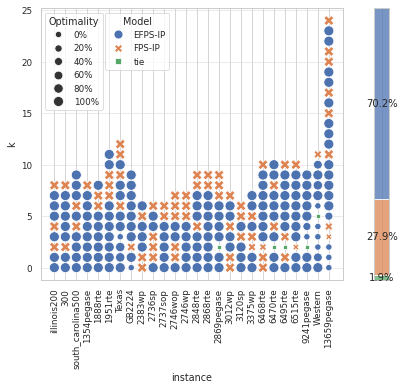

In [12]:
solvers = ["EFPS-IP","FPS-IP"]
show_best_solver(df2, solvers, success=True)

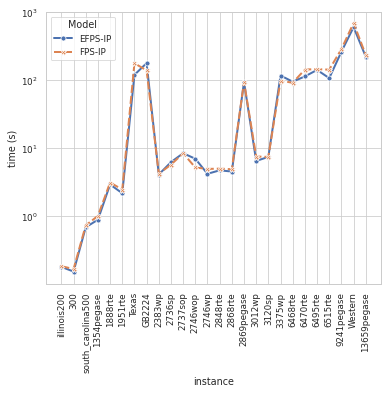

In [13]:
show_execution_time(df, solvers, log_scale=True)

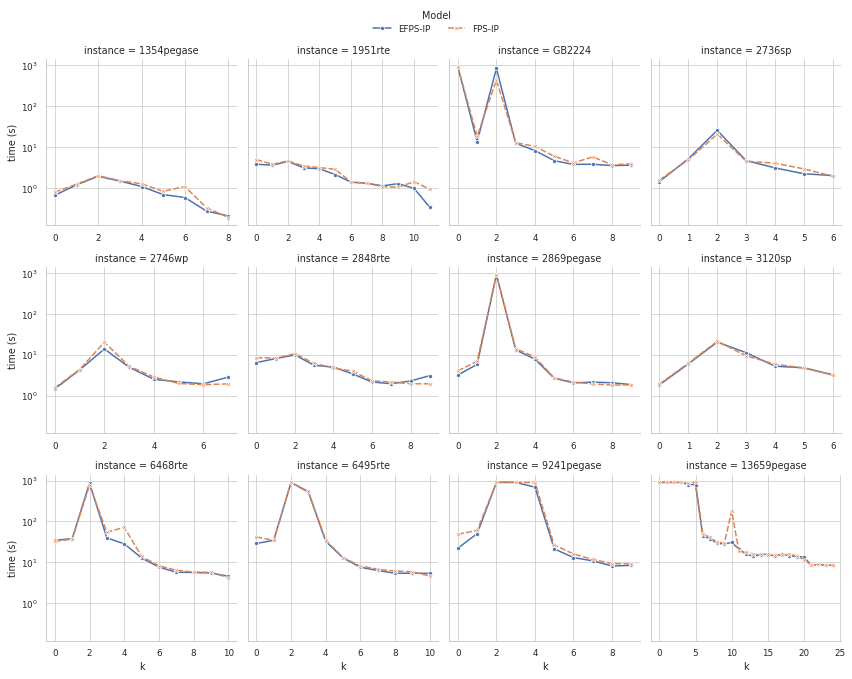

In [14]:
show_execution_time_grid(df, solvers, 12, 4, legend_xpos=0.45, log_scale=True, sharey=True)

## EFPS-IP: InP and OutP

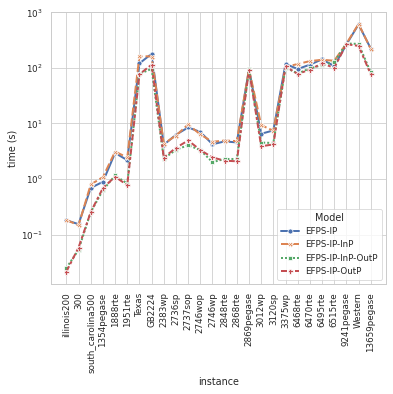

In [15]:
solvers = ["EFPS-IP", "EFPS-IP-InP", "EFPS-IP-InP-OutP", "EFPS-IP-OutP"]
show_execution_time(df, solvers, log_scale=True)

## EFPS-IP: Init

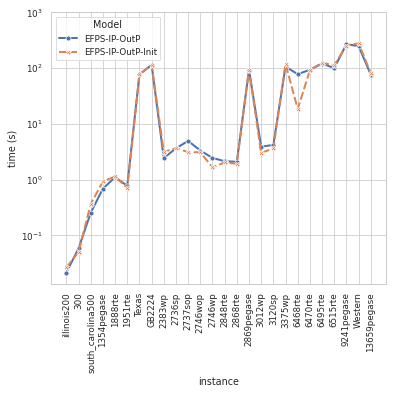

In [16]:
solvers = ["EFPS-IP-OutP", "EFPS-IP-OutP-Init"]
show_execution_time(df, solvers, log_scale=True)

## BRI-IP vs. JOV-IP vs. FORT-IP vs. EFPS-IP

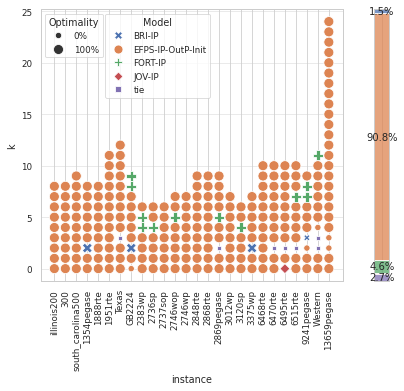

In [17]:
solvers = ["BRI-IP", "EFPS-IP-OutP-Init", "FORT-IP", "JOV-IP"]
show_best_solver(df2, solvers, success=True)

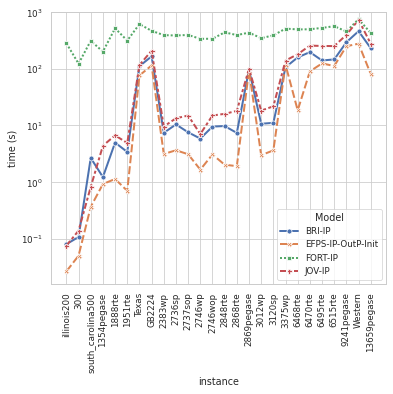

In [18]:
show_execution_time(df, solvers, log_scale=True)

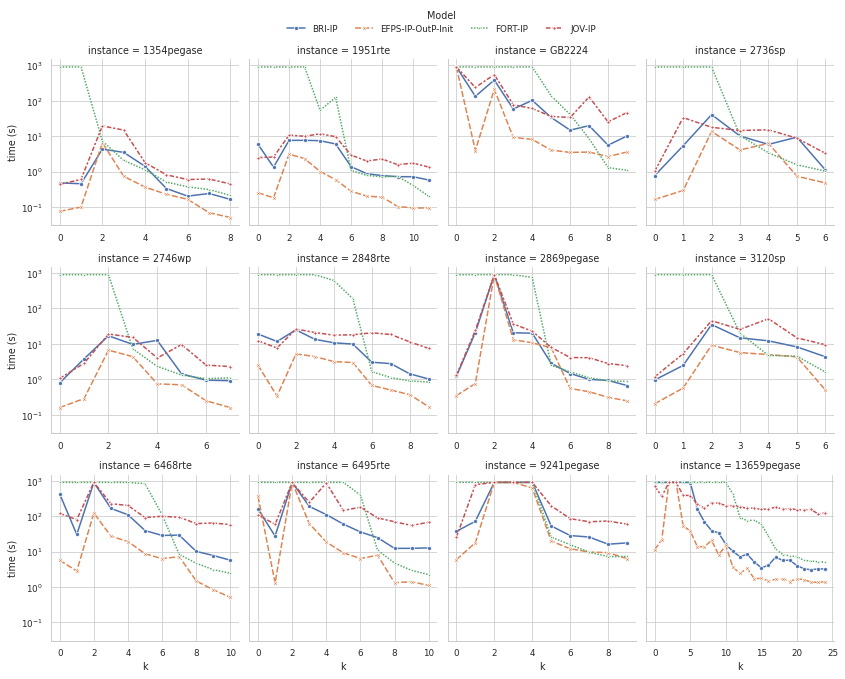

In [19]:
show_execution_time_grid(df, solvers, 12, 4, legend_xpos=0.39, log_scale=True)